<a href="https://colab.research.google.com/github/James-Patrick416/gitlab-project-analysis/blob/main/gitlab_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import requests

# Fetch 5 GitLab projects
response = requests.get("https://gitlab.com/api/v4/projects?per_page=5")
projects = response.json()

# Print each project
for project in projects:
    name = project.get('name', 'No name')
    stars = project.get('star_count', 0)
    url = project.get('web_url', 'No URL')

    print(f"📁 {name} | ⭐ {stars} | 🔗 {url}")

📁 homebrew-svvm | ⭐ 0 | 🔗 https://gitlab.com/project_anvil/homebrew-svvm
📁 project-with-security-findings-e35fbc63fb94999c | ⭐ 0 | 🔗 https://gitlab.com/gitlab-e2e-sandbox-group-3/e2e-test-2026-07-25-18-07-23-a01555271dc626db/project-with-security-findings-e35fbc63fb94999c
📁 golang | ⭐ 0 | 🔗 https://gitlab.com/socialmaps/golang
📁 puresky | ⭐ 0 | 🔗 https://gitlab.com/tunefriend/puresky
📁 RabbitMQ-test | ⭐ 0 | 🔗 https://gitlab.com/kloe.rl/rabbitmq-test


In [4]:
import requests
import csv
import time
from google.colab import files  # For downloading the CSV

# ==========================================
# FETCH 100 PUBLIC GITLAB PROJECTS
# ==========================================

all_projects = []
page = 1
per_page = 50  # Max per request

print("🔄 Fetching GitLab projects...\n")

while len(all_projects) < 100:
    url = f"https://gitlab.com/api/v4/projects?per_page={per_page}&page={page}"
    response = requests.get(url)
    projects = response.json()

    if not projects:
        break  # No more projects

    all_projects.extend(projects)
    print(f"📄 Fetched page {page} ({len(projects)} projects)")
    page += 1
    time.sleep(0.5)  # Be nice to the API

# Keep only first 100
all_projects = all_projects[:100]

print(f"\n✅ Total: {len(all_projects)} projects fetched\n")

# ==========================================
# SAVE TO CSV
# ==========================================

with open('gitlab_projects.csv', 'w', newline='', encoding='utf-8') as f:
    writer = csv.writer(f)
    # Headers
    writer.writerow(['Project Name', 'Description', 'Stars', 'Forks', 'URL', 'Created At', 'Last Activity'])

    for p in all_projects:
        writer.writerow([
            p.get('name', ''),
            (p.get('description', '') or '')[:100],  # Truncate long descriptions
            p.get('star_count', 0),
            p.get('forks_count', 0),
            p.get('web_url', ''),
            p.get('created_at', '')[:10],  # Just the date
            p.get('last_activity_at', '')[:10]
        ])

print("📊 CSV created: gitlab_projects.csv")
print("\n🔍 Preview (first 3 projects):")

# Show preview
import pandas as pd
df = pd.read_csv('gitlab_projects.csv')
print(df.head(3))

# Download the CSV to your computer
files.download('gitlab_projects.csv')

🔄 Fetching GitLab projects...

📄 Fetched page 1 (50 projects)
📄 Fetched page 2 (50 projects)

✅ Total: 100 projects fetched

📊 CSV created: gitlab_projects.csv

🔍 Preview (first 3 projects):
            Project Name Description  Stars  Forks  \
0  PhD Thesis Repository         NaN      0      0   
1    containers-template         NaN      0      0   
2                adhell3         NaN      0      0   

                                                 URL  Created At Last Activity  
0  https://gitlab.com/uniroma3/compunet/phd-thesi...  2026-07-25    2026-07-25  
1  https://gitlab.com/blockolepitchitchi4/contain...  2026-07-25    2026-07-25  
2                     https://gitlab.com/wlo/adhell3  2026-07-25    2026-07-25  


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [6]:
import pandas as pd
import sqlite3

# ==========================================
# LOAD CSV INTO SQL DATABASE
# ==========================================

# Read the CSV (make sure it's in Colab's file system)
df = pd.read_csv('gitlab_projects.csv')

# Create a SQLite database in memory
conn = sqlite3.connect(':memory:')
df.to_sql('projects', conn, index=False, if_exists='replace')

print("✅ Data loaded into SQL database")
print(f"📊 {len(df)} projects loaded\n")

# ==========================================
# SQL QUERY 1: Top 10 most starred projects
# ==========================================

query1 = """
SELECT
    "Project Name" as project,
    Stars,
    Forks,
    "Last Activity" as last_active
FROM projects
WHERE Stars > 0
ORDER BY Stars DESC
LIMIT 10
"""

print("⭐ TOP 10 MOST STARRED PROJECTS:")
print("-" * 60)
result1 = pd.read_sql(query1, conn)
print(result1.to_string(index=False))

# ==========================================
# SQL QUERY 2: Most active projects (recent activity)
# ==========================================

query2 = """
SELECT
    "Project Name" as project,
    "Last Activity" as last_active,
    Stars,
    Forks
FROM projects
WHERE "Last Activity" >= '2025-01-01'
ORDER BY "Last Activity" DESC
LIMIT 10
"""

print("\n🔄 TOP 10 MOST ACTIVE PROJECTS (2025+):")
print("-" * 60)
result2 = pd.read_sql(query2, conn)
print(result2.to_string(index=False))

# ==========================================
# SQL QUERY 3: Summary statistics
# ==========================================

query3 = """
SELECT
    COUNT(*) as total_projects,
    SUM(Stars) as total_stars,
    ROUND(AVG(Stars), 1) as avg_stars,
    MAX(Stars) as max_stars,
    SUM(Forks) as total_forks
FROM projects
"""

print("\n📊 SUMMARY STATISTICS:")
print("-" * 60)
result3 = pd.read_sql(query3, conn)
print(result3.to_string(index=False))

conn.close()

✅ Data loaded into SQL database
📊 100 projects loaded

⭐ TOP 10 MOST STARRED PROJECTS:
------------------------------------------------------------
Empty DataFrame
Columns: [project, Stars, Forks, last_active]
Index: []

🔄 TOP 10 MOST ACTIVE PROJECTS (2025+):
------------------------------------------------------------
                                        project last_active  Stars  Forks
                          PhD Thesis Repository  2026-07-25      0      0
                            containers-template  2026-07-25      0      0
                                        adhell3  2026-07-25      0      0
                                          t4tec  2026-07-25      0      0
                                             tm  2026-07-25      0      0
                  wiki_testing-a943f26bfe6f3aa1  2026-07-25      0      0
project-with-security-findings-cda99dfd95e7ac8f  2026-07-25      0      0
                                          t2tes  2026-07-25      0      0
             

📊 0 projects with at least 1 star



/tmp/ipykernel_1694/806057348.py:32: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


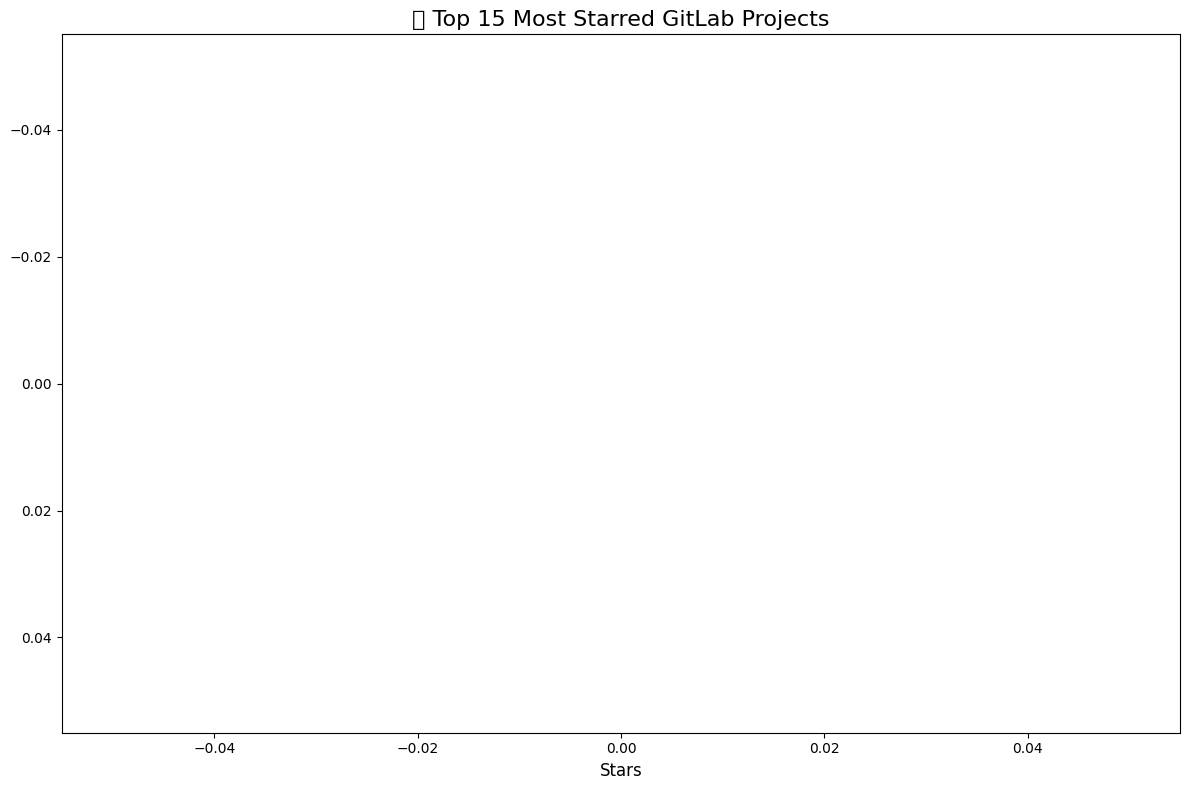

/tmp/ipykernel_1694/806057348.py:52: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


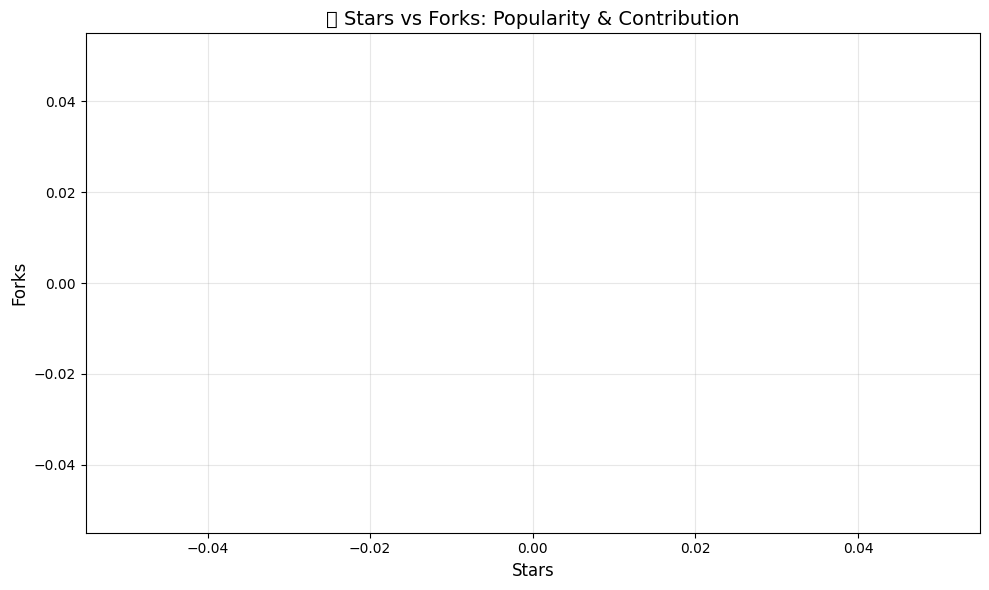

/tmp/ipykernel_1694/806057348.py:68: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


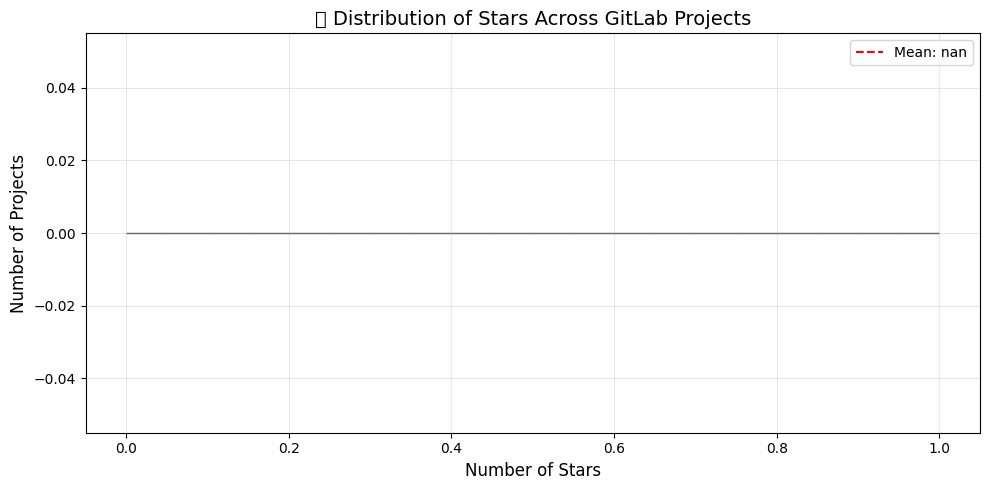

/tmp/ipykernel_1694/806057348.py:94: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


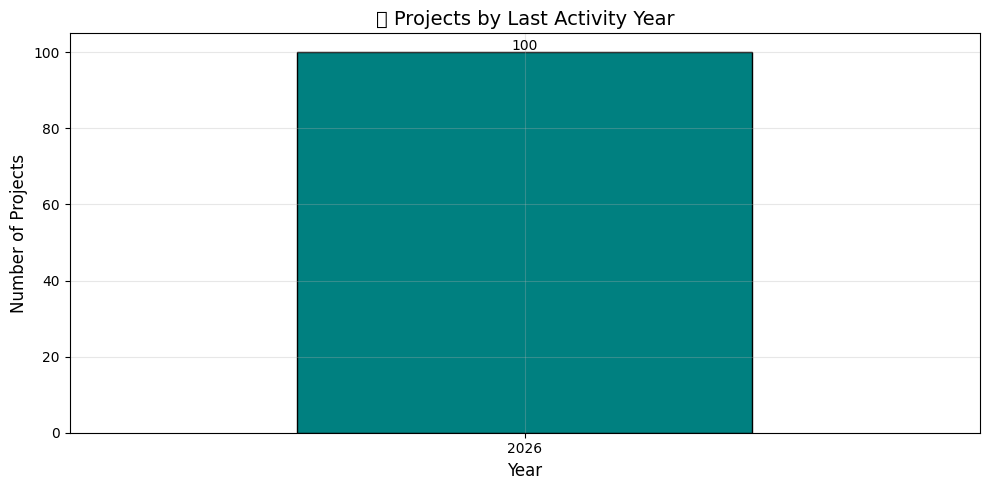


📊 KEY INSIGHTS FROM GITLAB PROJECT DATA
✅ Total projects analyzed: 100
✅ Projects with at least 1 star: 0
✅ Total stars across all projects: 0
✅ Average stars per project: 0.0
✅ Most active year: 2026 (100 projects)

🏆 MOST STARRED PROJECT:
   Name: PhD Thesis Repository
   Stars: 0
   Forks: 0
   Last Active: 2026-07-25


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# LOAD DATA
# ==========================================

df = pd.read_csv('gitlab_projects.csv')

# Clean: Remove projects with 0 stars for better visuals
df_filtered = df[df['Stars'] > 0].sort_values('Stars', ascending=False)

print(f"📊 {len(df_filtered)} projects with at least 1 star\n")

# ==========================================
# CHART 1: Top 15 Most Starred Projects (Bar Chart)
# ==========================================

plt.figure(figsize=(12, 8))
top15 = df_filtered.head(15)
bars = plt.barh(top15['Project Name'], top15['Stars'], color='skyblue')
plt.xlabel('Stars', fontsize=12)
plt.title('⭐ Top 15 Most Starred GitLab Projects', fontsize=16)
plt.gca().invert_yaxis()  # Highest at top

# Add value labels
for bar, stars in zip(bars, top15['Stars']):
    plt.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
             str(stars), va='center', fontsize=9)

plt.tight_layout()
plt.show()

# ==========================================
# CHART 2: Stars vs Forks (Scatter Plot)
# ==========================================

plt.figure(figsize=(10, 6))
plt.scatter(df_filtered['Stars'], df_filtered['Forks'], alpha=0.6, color='green')
plt.xlabel('Stars', fontsize=12)
plt.ylabel('Forks', fontsize=12)
plt.title('📊 Stars vs Forks: Popularity & Contribution', fontsize=14)
plt.grid(True, alpha=0.3)

# Annotate top projects
for _, row in df_filtered.head(5).iterrows():
    plt.annotate(row['Project Name'],
                 (row['Stars'], row['Forks']),
                 fontsize=8, alpha=0.7)

plt.tight_layout()
plt.show()

# ==========================================
# CHART 3: Distribution of Stars (Histogram)
# ==========================================

plt.figure(figsize=(10, 5))
plt.hist(df_filtered['Stars'], bins=20, color='orange', edgecolor='black', alpha=0.7)
plt.xlabel('Number of Stars', fontsize=12)
plt.ylabel('Number of Projects', fontsize=12)
plt.title('📈 Distribution of Stars Across GitLab Projects', fontsize=14)
plt.axvline(df_filtered['Stars'].mean(), color='red', linestyle='dashed',
            label=f'Mean: {df_filtered["Stars"].mean():.1f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ==========================================
# CHART 4: Activity Timeline (Last Activity)
# ==========================================

# Convert dates
df['Last Activity Date'] = pd.to_datetime(df['Last Activity'])
df['Activity Year'] = df['Last Activity Date'].dt.year

# Count projects by year
activity_by_year = df['Activity Year'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
activity_by_year.plot(kind='bar', color='teal', edgecolor='black')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Projects', fontsize=12)
plt.title('🔄 Projects by Last Activity Year', fontsize=14)
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3)

# Add value labels
for i, v in enumerate(activity_by_year):
    plt.text(i, v + 0.5, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# ==========================================
# SUMMARY INSIGHTS (Text)
# ==========================================

print("\n" + "="*60)
print("📊 KEY INSIGHTS FROM GITLAB PROJECT DATA")
print("="*60)

print(f"✅ Total projects analyzed: {len(df)}")
print(f"✅ Projects with at least 1 star: {len(df_filtered)}")
print(f"✅ Total stars across all projects: {df['Stars'].sum()}")
print(f"✅ Average stars per project: {df['Stars'].mean():.1f}")
print(f"✅ Most active year: {activity_by_year.idxmax()} ({activity_by_year.max()} projects)")

most_starred = df.loc[df['Stars'].idxmax()]
print(f"\n🏆 MOST STARRED PROJECT:")
print(f"   Name: {most_starred['Project Name']}")
print(f"   Stars: {most_starred['Stars']}")
print(f"   Forks: {most_starred['Forks']}")
print(f"   Last Active: {most_starred['Last Activity']}")